In [1]:
from numpy import zeros
from numpy import ones
from numpy.random import randn
from numpy.random import randint
from keras.datasets.cifar10 import load_data
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, LeakyReLU, Dropout

2026-02-11 20:52:23.860060: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-11 20:52:24.020282: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-11 20:52:24.020330: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-11 20:52:24.069736: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-11 20:52:24.877627: W tensorflow/stream_executor/platform/de

In [2]:
import matplotlib.pyplot as plt

In [3]:
(train_X, train_y), (test_X, test_y) = load_data()

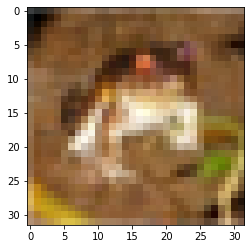

In [4]:
plt.imshow(train_X[0])

In [5]:
train_y[0]

array([6], dtype=uint8)

In [6]:
def define_discriminator():
  model = Sequential()
  model.add(Conv2D(128, (3, 3), padding='same', input_shape= (32, 32, 3)))
  model.add(LeakyReLU(0.2))
  model.add(Conv2D(128, (3, 3), padding='same'))
  model.add(LeakyReLU(0.2))


  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1, activation='sigmoid'))

  opt = Adam(lr=0.0002)
  model.compile(loss = 'binary_crossentropy', optimizer =opt, metrics=['accuracy'])

  return model


discr = define_discriminator()
print(discr.summary())



2026-02-11 20:52:27.658854: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-02-11 20:52:27.659751: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-11 20:52:27.659800: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (mhmud): /proc/driver/nvidia/version does not exist
2026-02-11 20:52:27.660886: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 128)       3584      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 128)       147584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 32, 32, 128)       0         
                                                                 
 flatten (Flatten)           (None, 131072)            0         
                                                                 
 dropout (Dropout)           (None, 131072)            0         
                                                                 
 dense (Dense)               (None, 1)                 1

/home/mhmud/.local/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [7]:
def define_generator(latent_dim):
  model = Sequential()
  model.add(Dense(8192, input_dim=latent_dim))
  model.add(LeakyReLU(0.2))
  model.add(Reshape((8, 8, 128)))
  model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(0.2))
  model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(0.2))

  model.add(Conv2D(3, (8, 8), activation='tanh', padding='same'))

  return model



gen = define_generator(100)
print(gen.summary())




Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 8192)              827392    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 8192)              0         
                                                                 
 reshape (Reshape)           (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 16, 16, 128)      262272    
 nspose)                                                         
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 32, 32, 128)      262272    
 ranspose)                                            

In [8]:
def define_gan(generator, discriminator):
  discriminator.trainable = False

  model = Sequential()
  model.add(generator)
  model.add(discriminator)

  opt = Adam(lr=0.0002)
  model.compile(loss = 'binary_crossentropy', optimizer =opt, metrics=['accuracy'])

  return model


In [9]:
def load_real_samples():
  (train_X, _), (_, _) = load_data()
  X = train_X.astype('float32')

  X = (X - 127.5) / 127.5


  return X

In [10]:
def generate_real_samples(dataset, n_samples):
  ix = randint(0, dataset.shape[0], n_samples)
  X = dataset[ix]
  y = ones((n_samples, 1))

  return X, y

In [11]:
def generate_latent_points(latent_dim, n_samples):
  X_input = randn(latent_dim*n_samples)
  X_input = X_input.reshape(n_samples, latent_dim)

  return X_input

In [12]:
def generate_fake_samples(generator, latent_dim, n_samples):
  X_input = generate_latent_points(latent_dim, n_samples)
  X = generator.predict(X_input)
  y = zeros((n_samples, 1 ))
  return X, y

In [13]:
def train(g_model, d_model, gan_model, dataset, latent_dim,n_epochs=6, n_batch=128 ):
  bat_per_epo = int(dataset.shape[0] / n_batch)
  #bat_per_epo = 100 # for time

  half_batch = int(n_batch / 2)

  for i in range(n_epochs):
    for j in range(bat_per_epo):
      X_real, y_real = generate_real_samples(dataset, half_batch)
      d_loss_real, _ = d_model.train_on_batch(X_real, y_real)

      X_fake, y_fake  = generate_fake_samples(g_model, latent_dim, half_batch)
      d_loss_fake, _ = d_model.train_on_batch(X_fake, y_fake)


      X_gan = generate_latent_points(latent_dim, n_batch)
      y_gan = ones((n_batch, 1))

      g_loss = gan_model.train_on_batch(X_gan, y_gan)

      print(i+1, j+1, bat_per_epo, d_loss_real, d_loss_fake, g_loss)

  g_model.save('generator_model.h5')

In [ ]:
latent_dim = 100
discriminator = define_discriminator()
generator = define_generator(latent_dim)
gan_model = define_gan(generator, discriminator)
dataset = load_real_samples()
train(generator, discriminator, gan_model, dataset, latent_dim, n_epochs=1)

2/2 [==============================] - 1s 202ms/step
1 1 390 0.6866511106491089 0.7060043811798096 [0.6772297024726868, 1.0]
2/2 [==============================] - 0s 211ms/step
1 2 390 0.2997881770133972 0.7472131252288818 [0.6366294622421265, 1.0]
2/2 [==============================] - 0s 202ms/step
1 3 390 0.12450224161148071 0.8222068548202515 [0.5773563385009766, 1.0]
2/2 [==============================] - 1s 265ms/step
1 4 390 0.05934979021549225 0.9150199890136719 [0.5354970693588257, 1.0]
2/2 [==============================] - 1s 283ms/step
1 5 390 0.029752757400274277 0.9498896598815918 [0.539108395576477, 1.0]
2/2 [==============================] - 1s 290ms/step
1 6 390 0.02741355076432228 0.8917302489280701 [0.6168672442436218, 1.0]
2/2 [==============================] - 0s 216ms/step
1 7 390 0.02222592942416668 0.7198261022567749 [0.808262288570404, 0.0]
2/2 [==============================] - 0s 199ms/step
1 8 390 0.023940663784742355 0.5106916427612305 [1.1328585147857666,

1 65 390 0.48927000164985657 0.2680649161338806 [2.188612461090088, 0.0]
2/2 [==============================] - 0s 194ms/step
1 66 390 0.5657132863998413 0.3528067469596863 [1.8143688440322876, 0.0]
2/2 [==============================] - 0s 202ms/step
1 67 390 0.590096652507782 0.44742923974990845 [1.6768289804458618, 0.0]
2/2 [==============================] - 0s 218ms/step
1 68 390 0.4521998465061188 0.3650650978088379 [2.1808018684387207, 0.0]
2/2 [==============================] - 0s 227ms/step
1 69 390 0.1664769947528839 0.17047865688800812 [3.143235921859741, 0.0]
2/2 [==============================] - 1s 251ms/step
1 70 390 0.10727714747190475 0.0969342365860939 [3.7081046104431152, 0.0]
2/2 [==============================] - 0s 192ms/step
1 71 390 0.07162977010011673 0.13902121782302856 [3.6013898849487305, 0.0]
2/2 [==============================] - 0s 218ms/step
1 72 390 0.025027573108673096 0.25773611664772034 [3.20272159576416, 0.0]
2/2 [==============================] - 0s

2/2 [==============================] - 0s 220ms/step
1 131 390 0.006279610563069582 2.566011119142786e-07 [14.336181640625, 0.0]
2/2 [==============================] - 1s 265ms/step
1 132 390 4.2408399167470634e-05 1.440481696590723e-06 [12.895383834838867, 0.0]
2/2 [==============================] - 1s 252ms/step
1 133 390 9.522895561531186e-05 5.4731176533096004e-06 [11.670313835144043, 0.0]
2/2 [==============================] - 1s 234ms/step
1 134 390 0.14998643100261688 2.0112805941607803e-05 [10.163341522216797, 0.0]
2/2 [==============================] - 0s 215ms/step
1 135 390 3.0955611691751983e-06 8.808963320916519e-05 [8.782853126525879, 0.0]
2/2 [==============================] - 1s 251ms/step
1 136 390 0.08176980912685394 0.00031572836451232433 [7.670322418212891, 0.0]
2/2 [==============================] - 0s 183ms/step
1 137 390 1.1962815182897657e-09 0.0008248609956353903 [6.704653739929199, 0.0]
2/2 [==============================] - 1s 248ms/step
1 138 390 1.951282234

In [ ]:
import keras
g_model = keras.models.load_model('generator_model.h5')

In [ ]:
#ref: https://github.com/bnsreenu/python_for_microscopists/blob/master/248_keras_implementation_of_GAN/248-cifar_GAN.py